In [227]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms
import csv


Found 438 complete flatness runs matching volume and geometry filters
Radius bounds: (0.0, 100) mm
Height bounds: (0.0, 100) mm
Thickness bounds: (0.0, 100) mm
Using /Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test/0p5to1_r5mmh1cm_bathed_1e9/0


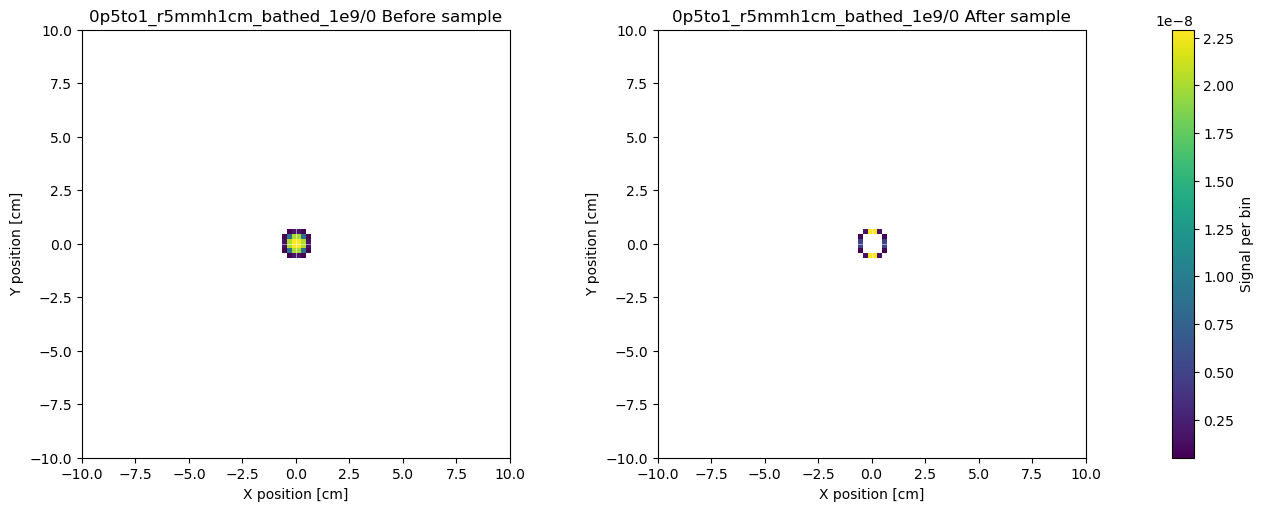

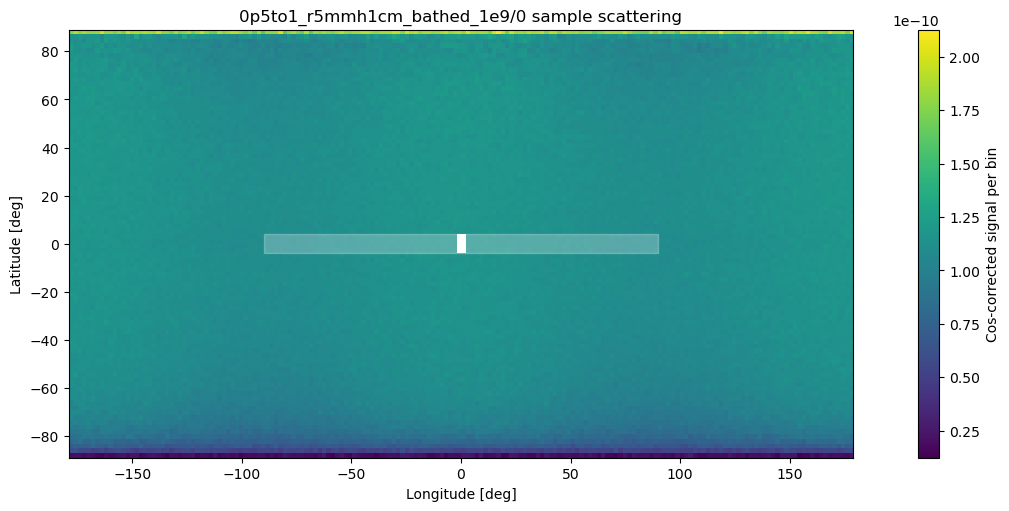

Flux before sample: 2.94498e-05
Flux after sample: 1.2006e-07
Flux hitting sample: 2.93298e-05
Beam area before sample: 1.58 cm^2
Cylinder radius: 5 mm
Cylinder height: 10 mm
Cylinder wall thickness: 0.5 mm
Cylinder volume: 0.2128 mm^3
Projected sample area: 1 cm^2
L_in: 0.212843 cm
Naive scattering probability: 0.0754919
Expected intensity: 2.1468e-10
Observed mean intensity in 180 degree window and +/-2 degree equator band: 1.12012e-10
Self absorption: 0.521762


In [228]:
# ============================================================
# User settings
# ============================================================
flatness_root = Path('geometry_optimization/cylinder_instrument/flatness_test')
if not flatness_root.exists():
    flatness_root = Path('/Users/christian/Documents/Study/bachelor_project') / flatness_root

Sigma_inc_cm_inv = 0.367
Sigma_coh_cm_inv = 1.786e-3
Sigma_s_cm_inv = Sigma_inc_cm_inv + Sigma_coh_cm_inv


required_monitor_files = ('cylinder_scattered.dat', 'before.dat', 'after.dat')
nominal_detector_center_deg = 0.0
center_offsets_deg = np.arange(-30.0, 30.1, 2.0)
detector_window_width_deg = 180

filtering_enabled = False
if filtering_enabled:
    minimum_sample_volume_cm3 = 1.0
    minimum_sample_volume_mm3 = minimum_sample_volume_cm3 * 1000.0
    radius_bounds_mm = (4.0, 13.0)
    height_bounds_mm = (7.0, 61.0)
    thickness_bounds_mm = (0.4, 3.5)
else:
    minimum_sample_volume_cm3 = 0.0
    minimum_sample_volume_mm3 = minimum_sample_volume_cm3 * 1000.0
    radius_bounds_mm = (0.0, 100)
    height_bounds_mm = (0.0, 100)
    thickness_bounds_mm = (0.0, 100)

low_outlier_fraction = 0.0
equator_band_halfwidth_local = 2.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0

# # Optional selectors. Leave as None to use the first complete flatness run.
# selected_scan_name = "1to3_r5mmh5cm_bathed_1e8n"
# selected_run_index = 0

selected_scan_name = None
selected_run_index = None

# ============================================================
# Helper functions
# ============================================================

def missing_monitor_files(run_dir):
    run_dir = Path(run_dir)
    return [name for name in required_monitor_files if not (run_dir / name).is_file()]


def is_complete_flatness_run(run_dir):
    return not missing_monitor_files(run_dir)


def value_in_bounds(value, bounds):
    lower, upper = bounds
    return lower <= value <= upper


def geometry_in_bounds(run_dir):
    try:
        geometry = parse_mccode_sim(geometry_metadata_file(run_dir))
    except (FileNotFoundError, ValueError):
        return False

    return (
        value_in_bounds(geometry['outer_radius_mm'], radius_bounds_mm)
        and value_in_bounds(geometry['outer_height_mm'], height_bounds_mm)
        and value_in_bounds(geometry['wall_thickness_mm'], thickness_bounds_mm)
    )


def numeric_sort_key(path):
    path = Path(path)
    try:
        run_number = int(path.name)
    except ValueError:
        run_number = path.name
    return (path.parent.name, run_number, str(path))


def find_complete_flatness_runs(root):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f'Flatness test directory does not exist: {root}')

    candidate_dirs = sorted({p.parent for p in root.rglob('cylinder_scattered.dat')})
    complete = [run_dir for run_dir in candidate_dirs if is_complete_flatness_run(run_dir)]
    filtered = [
        run_dir
        for run_dir in complete
        if (
            cylinder_volume(run_dir) >= minimum_sample_volume_mm3
            and geometry_in_bounds(run_dir)
        )
    ]
    return sorted(filtered, key=numeric_sort_key)


def select_flatness_run(runs, scan_name=None, run_index=None):
    selected = list(runs)
    if scan_name is not None:
        selected = [run_dir for run_dir in selected if run_dir.parent.name == scan_name]
    if run_index is not None:
        selected = [run_dir for run_dir in selected if run_dir.name == str(run_index)]
    if not selected:
        raise ValueError(
            f'No complete flatness run found for scan_name={scan_name!r}, run_index={run_index!r}'
        )
    return selected[0]


def parse_mccode_params(metadata_file):
    metadata_file = Path(metadata_file)
    params = {}
    pattern = re.compile(r'^\s*#?\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with metadata_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass
    return params


def parse_mccode_sim(sim_file):
    params = parse_mccode_params(sim_file)
    required = ['cylinder_radius', 'cylinder_height', 'thickness']
    missing = [key for key in required if key not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    return {
        'outer_radius_mm': params['cylinder_radius'] * 1000.0,
        'outer_height_mm': params['cylinder_height'] * 1000.0,
        'wall_thickness_mm': params['thickness'] * 1000.0,
    }


def geometry_metadata_file(run_dir):
    run_dir = Path(run_dir)
    for name in ('mccode.sim', 'cylinder_scattered.dat', 'before.dat', 'after.dat'):
        candidate = run_dir / name
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(f'No McCode metadata file found in {run_dir}')


def validate_flatness_run(run_dir):
    missing = missing_monitor_files(run_dir)
    if missing:
        raise FileNotFoundError(f'{run_dir} is missing required file(s): {missing}')
    return Path(run_dir)


def load_scattered_monitor(run_dir):
    run_dir = validate_flatness_run(run_dir)
    loaded = ms.load_data(str(run_dir))
    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    for item in loaded:
        name = str(getattr(item, 'name', '') or '')
        component = str(getattr(item, 'component_name', '') or '')
        filename = str(getattr(getattr(item, 'metadata', None), 'filename', '') or '')
        if (
            'cylinder_scattered' in name
            or 'cylinder_scattered' in filename
            or 'mon_4pi' in component
        ):
            return item

    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_corrected_heatmap_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    H = np.array(sphere_mon.Intensity, copy=True)
    H_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and H.shape == (meta.dimension[0], meta.dimension[1]):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )
    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    Lon, Lat = np.meshgrid(lon_centers, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        & (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    H_corr = np.where(~beam_center_mask, H_corr, np.nan)
    H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

    return lon_centers, lat_centers, H_corr, H_err_corr


def get_equator_cut_from_run(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)
    Hmc_err = np.array(sphere_mon.Error, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon = np.linspace(
        xmin + 0.5 * (xmax - xmin) / Hmc.shape[1],
        xmax - 0.5 * (xmax - xmin) / Hmc.shape[1],
        Hmc.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(lon, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        & (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    Hmc_corrected = np.where(~beam_center_mask, Hmc_corrected, np.nan)
    Hmc_err_corrected = np.where(~beam_center_mask, Hmc_err_corrected, np.nan)

    equator_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_local
    equator_band = Hmc_corrected[equator_band_mask, :]
    equator_band_err = Hmc_err_corrected[equator_band_mask, :]

    nonzero_band = equator_band > 0
    equator_band = np.where(nonzero_band, equator_band, np.nan)
    equator_band_err = np.where(nonzero_band, equator_band_err, np.nan)

    valid_counts = np.sum(~np.isnan(equator_band), axis=0)
    equator_sum = np.nansum(equator_band, axis=0)
    equator_cut = np.full(equator_band.shape[1], np.nan)
    np.divide(
        equator_sum,
        valid_counts,
        out=equator_cut,
        where=valid_counts > 0,
    )

    equator_err_sum = np.sqrt(np.nansum(equator_band_err**2, axis=0))
    equator_cut_err = np.full(equator_band.shape[1], np.nan)
    np.divide(
        equator_err_sum,
        valid_counts,
        out=equator_cut_err,
        where=valid_counts > 0,
    )

    valid_cols = (valid_counts > 0) & np.isfinite(equator_cut) & (equator_cut > 0)
    if np.any(valid_cols):
        low_outlier_threshold = low_outlier_fraction * np.nanmedian(equator_cut[valid_cols])
        valid_cols = valid_cols & (equator_cut >= low_outlier_threshold)

    return lon, equator_cut, equator_cut_err, valid_cols


def cylinder_volume_cm3(run_dir):
    validate_flatness_run(run_dir)
    params = parse_mccode_sim(geometry_metadata_file(run_dir))
    r = params['outer_radius_mm']
    h = params['outer_height_mm']
    t = params['wall_thickness_mm']
    inner_r = r - t
    inner_h = h - 2 * t
    if inner_r <= 0 or inner_h <= 0:
        return 0.0
    return np.pi * ((r**2 * h) - (inner_r**2 * inner_h)) / 1000.0

def side_wall_volume_cm3(run_dir):
    validate_flatness_run(run_dir)
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))
    R_cm = geometry['outer_radius_mm'] / 10.0
    H_cm = geometry['outer_height_mm'] / 10.0
    t_cm = geometry['wall_thickness_mm'] / 10.0
    r_cm = R_cm - t_cm
    return np.pi * (R_cm**2 - r_cm**2) * H_cm


def flux_at_sample(run_dir):
    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata
    Hmc = np.array(sphere_mon.Intensity, copy=True)

    if hasattr(meta, 'dimension') and Hmc.shape == (meta.dimension[0], meta.dimension[1]):
        Hmc = Hmc.T

    xmin, xmax, ymin, ymax = meta.limits
    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )
    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / Hmc.shape[1],
        xmax - 0.5 * (xmax - xmin) / Hmc.shape[1],
        Hmc.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)
    Hmc_corrected = Hmc / safe_cos

    Lon, Lat = np.meshgrid(lon_centers, lat_centers)
    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        & (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )
    return np.nansum(Hmc_corrected[beam_center_mask])


def load_mccode_2d(path):
    path = Path(path)
    meta = {}
    nrows = None
    data_rows = []
    in_data = False
    with path.open() as f:
        for line in f:
            if line.startswith('# type: array_2d'):
                dims = line.split('array_2d(', 1)[1].split(')', 1)[0]
                nrows = int(dims.split(',')[1].strip())
            elif line.startswith('# xylimits:'):
                meta['extent'] = [float(v) for v in line.split(':', 1)[1].split()]
            elif line.startswith('# component:'):
                meta['component'] = line.split(':', 1)[1].strip()
            elif line.startswith('# Data'):
                in_data = True
            elif in_data and line.startswith('#'):
                break
            elif in_data and line.strip():
                data_rows.append([float(v) for v in line.split()])
                if nrows is not None and len(data_rows) == nrows:
                    break

    if nrows is None:
        raise ValueError(f'Could not find array_2d dimensions in {path}')
    if len(data_rows) != nrows:
        raise ValueError(f'Expected {nrows} rows from {path}, got {len(data_rows)}')

    data = np.array(data_rows)
    return data, meta


def before_after_intensity(run_dir):
    run_dir = validate_flatness_run(run_dir)
    before_data, _ = load_mccode_2d(run_dir / 'before.dat')
    after_data, _ = load_mccode_2d(run_dir / 'after.dat')
    return np.nansum(before_data), np.nansum(after_data)


def intensity_hitting_sample(run_dir):
    before_intensity, after_intensity = before_after_intensity(run_dir)
    return before_intensity - after_intensity





def projected_area_cm2(run_dir):
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))
    radius_cm = geometry['outer_radius_mm'] / 10.0
    height_cm = geometry['outer_height_mm'] / 10.0
    # Side-view projected area of the cylinder.
    return 2.0 * radius_cm * height_cm



def mean_incoming_path_length_cm(run_dir):
    material_volume_cm3 = cylinder_volume_cm3(run_dir)
    return material_volume_cm3 / projected_area_cm2(run_dir)


def naive_scattering_probability(run_dir):
    """
    Naive no-absorption incoherent scattering probability.
    Uses mean incoming side-wall path length.
    """
    L_mean = mean_incoming_path_length_cm(run_dir)
    return 1.0 - np.exp(-Sigma_s_cm_inv * L_mean)

def solid_angle_bin_sr(dlon_deg=2.0, lat_center_deg=0.0, dlat_deg=2.0):
    dphi = np.deg2rad(dlon_deg)
    lat1 = np.deg2rad(lat_center_deg - dlat_deg / 2.0)
    lat2 = np.deg2rad(lat_center_deg + dlat_deg / 2.0)
    return dphi * (np.sin(lat2) - np.sin(lat1))

def expected_intensity(run_dir):
    solid_angle = solid_angle_bin_sr(dlon_deg=2.0, lat_center_deg=0.0, dlat_deg=2.0)
    return (
        intensity_hitting_sample(run_dir)
        * naive_scattering_probability(run_dir)
        * solid_angle
        / (4 * np.pi)
    )


def angular_window_mask(angles_deg, center_deg, width_deg):
    half_width = width_deg / 2.0
    wrapped_delta = (angles_deg - center_deg + 180.0) % 360.0 - 180.0
    return np.abs(wrapped_delta) <= half_width


def mean_intensity_in_detector_window(
    run_dir,
    center_deg=nominal_detector_center_deg,
    width_deg=detector_window_width_deg,
):
    lon, equator_cut, _, valid_cols = get_equator_cut_from_run(run_dir)
    detector_mask = angular_window_mask(lon, center_deg, width_deg)
    observed = equator_cut[detector_mask & valid_cols]
    if observed.size == 0:
        raise ValueError(
            f'No valid observed intensities in {width_deg:g} degree window centered at {center_deg:g} degree'
        )
    return np.nanmean(observed)


def self_absorption(run_dir):
    observed_mean_intensity = mean_intensity_in_detector_window(run_dir)
    return observed_mean_intensity / expected_intensity(run_dir)


flatness_run_dirs = find_complete_flatness_runs(flatness_root)
if not flatness_run_dirs:
    raise FileNotFoundError(
        f'No complete flatness runs found under {flatness_root}; each run needs {required_monitor_files} '
        f'and volume >= {minimum_sample_volume_cm3:g} cm^3, '
        f'radius in {radius_bounds_mm} mm, height in {height_bounds_mm} mm, '
        f'thickness in {thickness_bounds_mm} mm'
    )

fhit_dir = select_flatness_run(
    flatness_run_dirs,
    scan_name=selected_scan_name,
    run_index=selected_run_index,
)
print(f'Found {len(flatness_run_dirs)} complete flatness runs matching volume and geometry filters')
print(f'Radius bounds: {radius_bounds_mm} mm')
print(f'Height bounds: {height_bounds_mm} mm')
print(f'Thickness bounds: {thickness_bounds_mm} mm')
print(f'Using {fhit_dir}')

before, before_meta = load_mccode_2d(fhit_dir / 'before.dat')
after, after_meta = load_mccode_2d(fhit_dir / 'after.dat')
extent = before_meta.get('extent', [-10, 10, -10, 10])

fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, image, title in [
    (axs[0], before, 'Before sample'),
    (axs[1], after, 'After sample'),
]:
    im = ax.imshow(
        np.ma.masked_less_equal(image, 0),
        extent=extent,
        origin='lower',
        aspect='equal',
        cmap='viridis',
    )
    ax.set_title(f'{fhit_dir.parent.name}/{fhit_dir.name} {title}')
    ax.set_xlabel('X position [cm]')
    ax.set_ylabel('Y position [cm]')
    ax.axhline(0, color='white', lw=0.7, alpha=0.5)
    ax.axvline(0, color='white', lw=0.7, alpha=0.5)

fig.colorbar(im, ax=axs, label='Signal per bin')
plt.show()

lon_centers, lat_centers, sample_heatmap, _ = get_corrected_heatmap_from_run(fhit_dir)
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
im = ax.imshow(
    np.ma.masked_invalid(np.ma.masked_less_equal(sample_heatmap, 0)),
    extent=[lon_centers[0], lon_centers[-1], lat_centers[0], lat_centers[-1]],
    origin='lower',
    aspect='auto',
    cmap='viridis',
)
ax.set_title(f'{fhit_dir.parent.name}/{fhit_dir.name} sample scattering')
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
top_window = 0.5 + equator_band_halfwidth_local * 1/90
bottom_window = 0.5 - equator_band_halfwidth_local * 1/90
window_left = nominal_detector_center_deg - detector_window_width_deg / 2.0
window_right = nominal_detector_center_deg + detector_window_width_deg / 2.0
ax.axvspan(window_left, window_right, ymin=bottom_window, ymax=top_window, color='white', alpha=0.25)
fig.colorbar(im, ax=ax, label='Cos-corrected signal per bin')
plt.show()

bin_width_x = (extent[1] - extent[0]) / before.shape[1]
bin_width_y = (extent[3] - extent[2]) / before.shape[0]
bin_area = abs(bin_width_x * bin_width_y)
beam_area_cm2 = np.count_nonzero(before > 0) * bin_area
flux_before = np.nansum(before)
flux_after = np.nansum(after)
flux_on_sample = flux_before - flux_after

print(f'Flux before sample: {flux_before:.6g}')
print(f'Flux after sample: {flux_after:.6g}')
print(f'Flux hitting sample: {flux_on_sample:.6g}')
sample_geometry = parse_mccode_sim(geometry_metadata_file(fhit_dir))

print(f'Beam area before sample: {beam_area_cm2:.4g} cm^2')
print(f"Cylinder radius: {sample_geometry['outer_radius_mm']:.4g} mm")
print(f"Cylinder height: {sample_geometry['outer_height_mm']:.4g} mm")
print(f"Cylinder wall thickness: {sample_geometry['wall_thickness_mm']:.4g} mm")
print(f'Cylinder volume: {cylinder_volume_cm3(fhit_dir):.4g} mm^3')
print(f"Projected sample area: {projected_area_cm2(fhit_dir):.6g} cm^2")
print(f"L_in: {mean_incoming_path_length_cm(fhit_dir):.6g} cm")
print(f"Naive scattering probability: {naive_scattering_probability(fhit_dir):.6g}")
print(f'Expected intensity: {expected_intensity(fhit_dir):.6g}')
print(f'Observed mean intensity in {detector_window_width_deg:g} degree window and +/-{equator_band_halfwidth_local:g} degree equator band: {mean_intensity_in_detector_window(fhit_dir):.6g}')
print(f'Self absorption: {self_absorption(fhit_dir):.6g}')


Computed self absorption for 438 valid runs
Min self absorption: 0.134474
Median self absorption: 0.4707
Mean self absorption: 0.471279
Max self absorption: 0.815318
Lowest self absorption values
  0.134474  1to3_r2cmh1cm_bathed_1e9/8  r=20 mm, h=10 mm, t=3 mm, V=8.935 mm^3
  0.145229  1to3_r2cmh1cm_bathed_1e9/7  r=20 mm, h=10 mm, t=2.75 mm, V=8.36 mm^3
  0.155825  1to3_r2cmh1cm_bathed_1e9/6  r=20 mm, h=10 mm, t=2.5 mm, V=7.756 mm^3
  0.16601  1to3_r2cmh1cm_bathed_1e9/5  r=20 mm, h=10 mm, t=2.25 mm, V=7.122 mm^3
  0.175538  1to3_r2cmh1cm_bathed_1e9/4  r=20 mm, h=10 mm, t=2 mm, V=6.459 mm^3
Highest self absorption values
  0.815318  0p5to2_r5mmh70mm_bathed_1e9/0  r=5 mm, h=70 mm, t=0.5 mm, V=1.108 mm^3
  0.808063  0p5to1_r5mmh6cm_bathed_1e9/0  r=5 mm, h=60 mm, t=0.5 mm, V=0.959 mm^3
  0.79535  0p5to1_r5mmh5cm_bathed_1e9/0  r=5 mm, h=50 mm, t=0.5 mm, V=0.8097 mm^3
  0.786697  0p5to2_r7mmh70mm_bathed_1e9/0  r=7 mm, h=70 mm, t=0.5 mm, V=1.617 mm^3
  0.782226  0p5to1_r5mmh6cm_bathed_1e9/1  

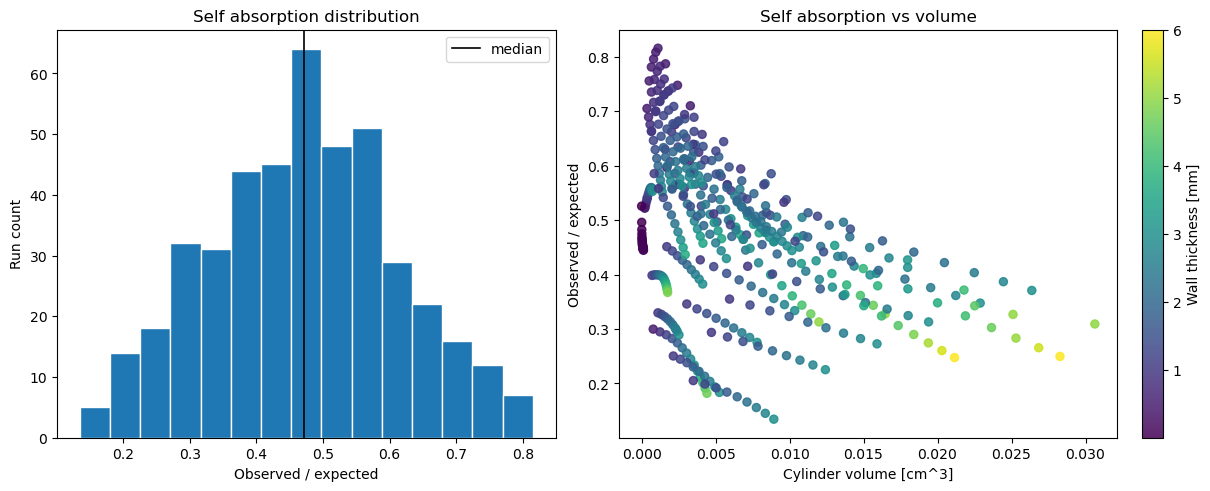

In [229]:
def self_absorption_result_row(run_dir):
    geometry = parse_mccode_sim(geometry_metadata_file(run_dir))
    before_intensity, after_intensity = before_after_intensity(run_dir)
    observed = mean_intensity_in_detector_window(run_dir)
    expected = expected_intensity(run_dir)
    absorption = observed / expected

    return {
        'run_dir': Path(run_dir),
        'scan': Path(run_dir).parent.name,
        'run': Path(run_dir).name,
        'radius_mm': geometry['outer_radius_mm'],
        'height_mm': geometry['outer_height_mm'],
        'thickness_mm': geometry['wall_thickness_mm'],
        'volume_mm3': cylinder_volume_cm3(run_dir),
        'intensity_before': before_intensity,
        'intensity_after': after_intensity,
        'intensity_hitting_sample': before_intensity - after_intensity,
        'expected_intensity': expected,
        'observed_mean_intensity': observed,
        'self_absorption': absorption,
    }


def compute_self_absorption_results(run_dirs):
    rows = []
    failed = []
    for run_dir in run_dirs:
        try:
            rows.append(self_absorption_result_row(run_dir))
        except Exception as exc:
            failed.append((Path(run_dir), exc))
    return rows, failed


def print_self_absorption_rows(rows, title, limit=5):
    print(title)
    for row in rows[:limit]:
        print(
            f"  {row['self_absorption']:.6g}  "
            f"{row['scan']}/{row['run']}  "
            f"r={row['radius_mm']:.3g} mm, "
            f"h={row['height_mm']:.3g} mm, "
            f"t={row['thickness_mm']:.3g} mm, "
            f"V={row['volume_mm3']:.4g} mm^3"
        )


self_absorption_rows, failed_self_absorption_runs = compute_self_absorption_results(flatness_run_dirs)
self_absorption_rows = [
    row for row in self_absorption_rows
    if np.isfinite(row['self_absorption']) and row['expected_intensity'] > 0
]

if not self_absorption_rows:
    raise ValueError('No finite self-absorption values were computed')

self_absorption_values = np.array([row['self_absorption'] for row in self_absorption_rows])
volumes_mm3 = np.array([row['volume_mm3'] for row in self_absorption_rows])
thickness_values = np.array([row['thickness_mm'] for row in self_absorption_rows])

print(f'Computed self absorption for {len(self_absorption_rows)} valid runs')
if failed_self_absorption_runs:
    print(f'Skipped {len(failed_self_absorption_runs)} runs that failed during computation')

print(f'Min self absorption: {np.min(self_absorption_values):.6g}')
print(f'Median self absorption: {np.median(self_absorption_values):.6g}')
print(f'Mean self absorption: {np.mean(self_absorption_values):.6g}')
print(f'Max self absorption: {np.max(self_absorption_values):.6g}')

sorted_by_absorption = sorted(self_absorption_rows, key=lambda row: row['self_absorption'])
print_self_absorption_rows(sorted_by_absorption, 'Lowest self absorption values')
print_self_absorption_rows(list(reversed(sorted_by_absorption)), 'Highest self absorption values')
fig, axs = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

axs[0].hist(self_absorption_values, bins=15, color='tab:blue', edgecolor='white')
axs[0].axvline(np.median(self_absorption_values), color='black', lw=1.2, label='median')
axs[0].set_title('Self absorption distribution')
axs[0].set_xlabel('Observed / expected')
axs[0].set_ylabel('Run count')
axs[0].legend()

scatter = axs[1].scatter(
    volumes_mm3 / 1000.0,
    self_absorption_values,
    c=thickness_values,
    cmap='viridis',
    s=34,
    alpha=0.85,
)
axs[1].set_title('Self absorption vs volume')
axs[1].set_xlabel('Cylinder volume [cm^3]')
axs[1].set_ylabel('Observed / expected')
fig.colorbar(scatter, ax=axs[1], label='Wall thickness [mm]')

plt.show()


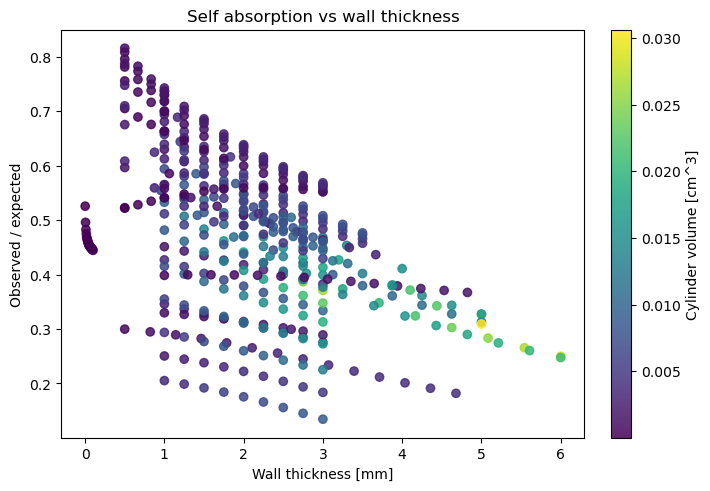

In [230]:
thickness_values = np.array([row['thickness_mm'] for row in self_absorption_rows])
self_absorption_values = np.array([row['self_absorption'] for row in self_absorption_rows])
volume_values_cm3 = np.array([row['volume_mm3'] for row in self_absorption_rows]) / 1000.0

fig, ax = plt.subplots(figsize=(7, 4.8), constrained_layout=True)
scatter = ax.scatter(
    thickness_values,
    self_absorption_values,
    c=volume_values_cm3,
    cmap='viridis',
    s=36,
    alpha=0.85,
)
ax.set_title('Self absorption vs wall thickness')
ax.set_xlabel('Wall thickness [mm]')
ax.set_ylabel('Observed / expected')
fig.colorbar(scatter, ax=ax, label='Cylinder volume [cm^3]')
plt.show()


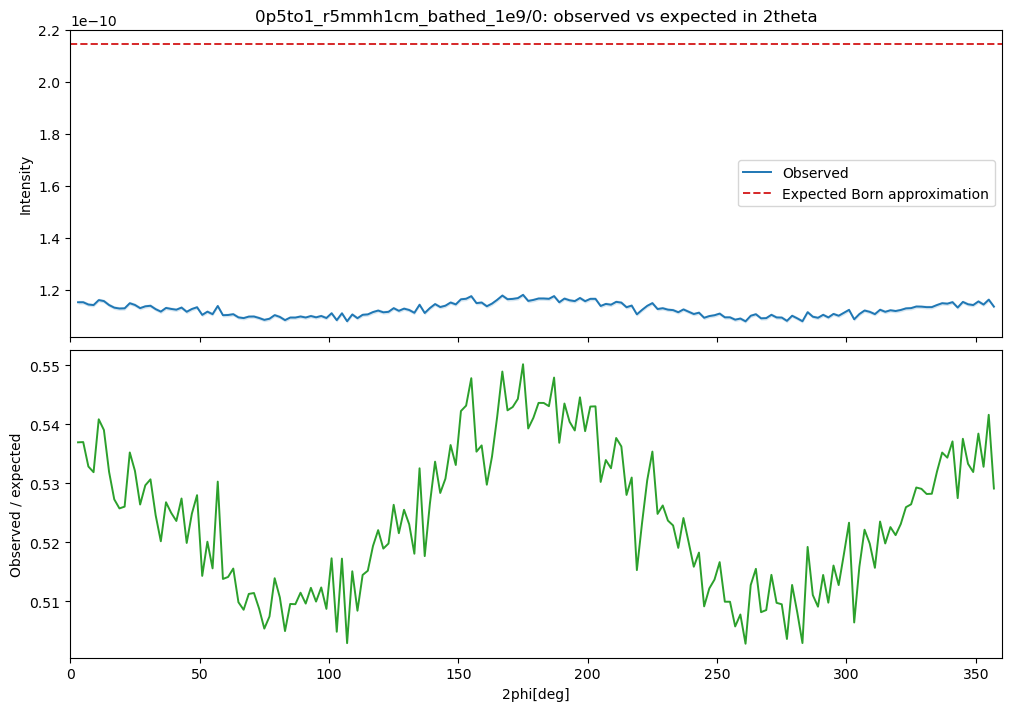

In [231]:
lon_deg, observed_cut, observed_cut_err, valid_cols = get_equator_cut_from_run(fhit_dir)
expected_born = expected_intensity(fhit_dir)

two_theta_deg = (lon_deg + 360.0) % 360.0
sort_idx = np.argsort(two_theta_deg)

two_theta_sorted = two_theta_deg[sort_idx]
observed_sorted = observed_cut[sort_idx]
observed_err_sorted = observed_cut_err[sort_idx]
valid_sorted = valid_cols[sort_idx] & np.isfinite(observed_sorted) & (observed_sorted > 0)
ratio_sorted = np.full_like(observed_sorted, np.nan, dtype=float)
ratio_sorted[valid_sorted] = observed_sorted[valid_sorted] / expected_born

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

axs[0].plot(
    two_theta_sorted[valid_sorted],
    observed_sorted[valid_sorted],
    color='tab:blue',
    lw=1.4,
    label='Observed',
)
axs[0].fill_between(
    two_theta_sorted[valid_sorted],
    observed_sorted[valid_sorted] - observed_err_sorted[valid_sorted],
    observed_sorted[valid_sorted] + observed_err_sorted[valid_sorted],
    color='tab:blue',
    alpha=0.18,
    linewidth=0,
)
axs[0].axhline(
    expected_born,
    color='tab:red',
    lw=1.4,
    linestyle='--',
    label='Expected Born approximation',
)
axs[0].set_title(f'{fhit_dir.parent.name}/{fhit_dir.name}: observed vs expected in 2theta')
axs[0].set_ylabel('Intensity')
axs[0].legend()

axs[1].plot(
    two_theta_sorted[valid_sorted],
    ratio_sorted[valid_sorted],
    color='tab:green',
    lw=1.4,
)
axs[1].set_xlabel('2phi[deg]')
axs[1].set_ylabel('Observed / expected')
axs[1].set_xlim(0, 360)

plt.show()
